# 15 · 192090 TIGER 차이나CSI300 — Final EDA (Phase 00.5)

> 기간 2019-01-03 ~ 2026-10-02 · n=1902 일간 로그수익률 (FDR Close, 분배 소급조정 추정 · DEC-3) · UNIVERSE_STATUS=PROVISIONAL.
> 이 notebook 의 모든 수치는 `scripts/build_final_notebooks.py` 가 `src/final_figs.compute()` 로 사전계산해 적었고, 아래 코드 셀이 같은 함수로 그림을 다시 그린다.

## 왜 이런 ETF인가
| 항목 | 값 |
|---|---|
| asset_scope / category | foreign_equity / broad_market |
| benchmark (상품 기초) | CSI 300 |
| 배율 / 환헤지 / 복제 | none / unhedged (추정) / synthetic (추정; 스왑/현물 혼합 가능) |
| peer_group | CN_equity |
| 비교 기준 ① proxy | 069500 KODEX 200 |
| 비교 기준 ② market reference | 069500 KODEX 200 |

카드(reports/ETF_CARDS/15_192090.md) 정체성 요약:
- [OBS] foreign_equity / broad_market / CSI 300 / peer_group CN_equity / 비헤지(추정) / synthetic(추정) / 중국장(KST 10:30~16:00)과 부분 중첩. confidence=low.
- [ANA] 중국 휴장(춘절·국경절) 중에도 KRX 에서는 거래 → 기초자산 가격 없이 거래되는 날이 생김.

## 핵심 수치
| ann_vol | 2026 vol | 2026 / 2019-25 | ex_kurt (trim3) | Q01 / Q99 | Max DD | β·ρ vs proxy | β·ρ vs market | |rz60|>3 (+/−) |
|---|---|---|---|---|---|---|---|---|
| 20.3% | 19.2% | 0.94× | 6.1 (3.2) | -3.37% / 3.43% | -41.4% (2024-02-02) | 0.20 · 0.277 | 0.20 · 0.277 | 29 / 26 |

정의: ann_vol=std·√252 · ex_kurt=Fisher(편향보정) · trim3=|r| 상위 3일 제거 · rz60=(r−직전60일 median)/(1.4826·직전60일 MAD), shift(1) · β/ρ=동일일 OLS·Pearson.

In [1]:
import sys
from pathlib import Path
ROOT = next(q for q in [Path.cwd(), *Path.cwd().parents] if (q / "config" / "universe.csv").exists())
sys.path.insert(0, str(ROOT))
%matplotlib inline
import pandas as pd
from src import final_figs as F
TK = "192090"
c = F.Ctx(TK)
S = F.compute(TK, c.close, c.vol, c.R)
pd.Series({k: v for k, v in S.items() if not isinstance(v, (dict, list))}).to_frame("value")

,value
ticker,192090
name,TIGER 차이나CSI300
proxy,069500
market,069500
proxy_name,KODEX 200
market_name,KODEX 200
n_obs,1902
start,2019-01-03
end,2026-10-02
ann_vol,0.202995


## Fig 1. 가격(로그축)과 고점 대비 낙폭

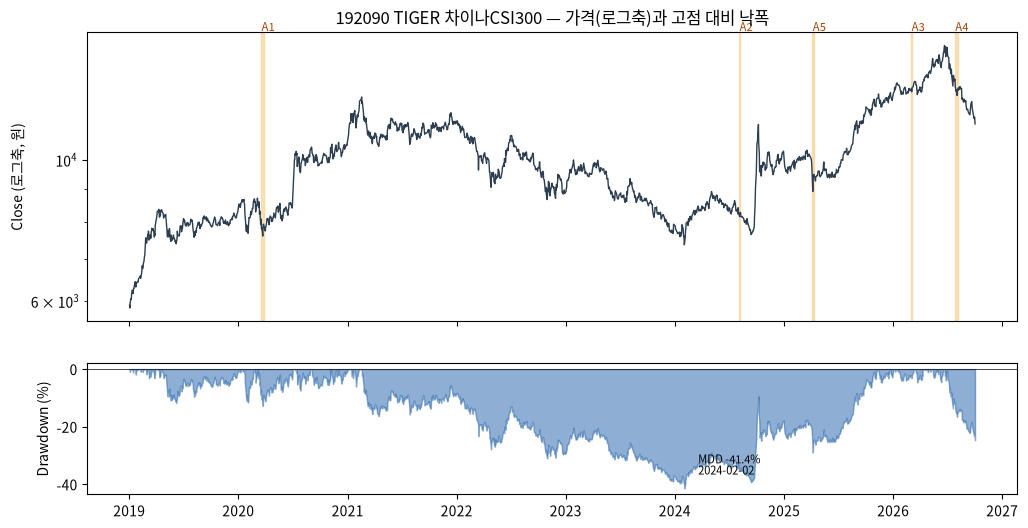

In [2]:
F.fig01_price_drawdown(c)

**WHAT THIS FIGURE MEASURES** — 위: FDR Close 로그축 (같은 높이 = 같은 % 변화). 아래: 직전 최고가 대비 낙폭 %. 주황 띠 = config/event_anchors.csv 공통충격 anchor.

**WHAT WE SEE** — 누적 로그수익률 65.7%. 최대낙폭 -41.4% (저점 2024-02-02, 고점 2021-02-17, 회복 2025-11-13). 마지막 날 낙폭 -24.7%.

**WHY IT MATTERS FINANCIALLY** — 낙폭 깊이와 회복 시간은 변동성 한 숫자가 보여주지 못하는 '보유자가 실제로 겪는 손실 경로'다. 같은 변동성이라도 회복 기간이 길면 자금 회수 위험이 크다.

**WHAT WE CANNOT CONCLUDE** — 낙폭이 기초지수 하락인지 분배·추적 차이인지는 기초지수/NAV 없이 분리하지 못한다. 미래 낙폭 확률을 이 경로 하나로 추정할 수 없다.

## Fig 2. 일간 수익률과 조건부 ±3σ 밴드

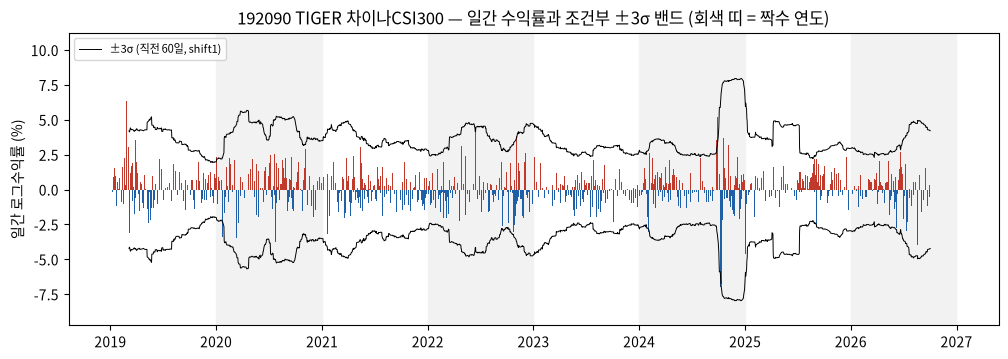

In [3]:
F.fig02_return_ts(c)

**WHAT THIS FIGURE MEASURES** — 막대 = 일간 로그수익률 (빨강 +, 파랑 −). 검은 선 = 직전 60일 표준편차 ×3 (shift(1), 당일 미포함). 회색 띠 = 짝수 연도.

**WHAT WE SEE** — 최대 상승 10.28% (2024-10-02), 최대 하락 -8.78% (2025-04-07). 변동성 최고 연도 2024 (24.6%), 최저 2023 (15.1%). 밴드 폭이 시기마다 달라 변동성 군집이 보인다.

**WHY IT MATTERS FINANCIALLY** — 고정 절대 threshold 대신 조건부(직전 변동성 대비) 기준을 써야 하는 근거다. 같은 −3% 도 저변동기에는 극단, 고변동기에는 평범하다.

**WHAT WE CANNOT CONCLUDE** — dq_flags.csv 가 2024-10-07, 2024-10-08 을 isolated_spike_reversal(다음날 되돌림) 후보로 표시한다. 이 날의 극단값이 기초자산 움직임인지 ETF 가격 괴리인지는 NAV 없이 구분할 수 없다.

## Fig 3. 수익률 분포 · Q-Q · 꼬리 생존함수

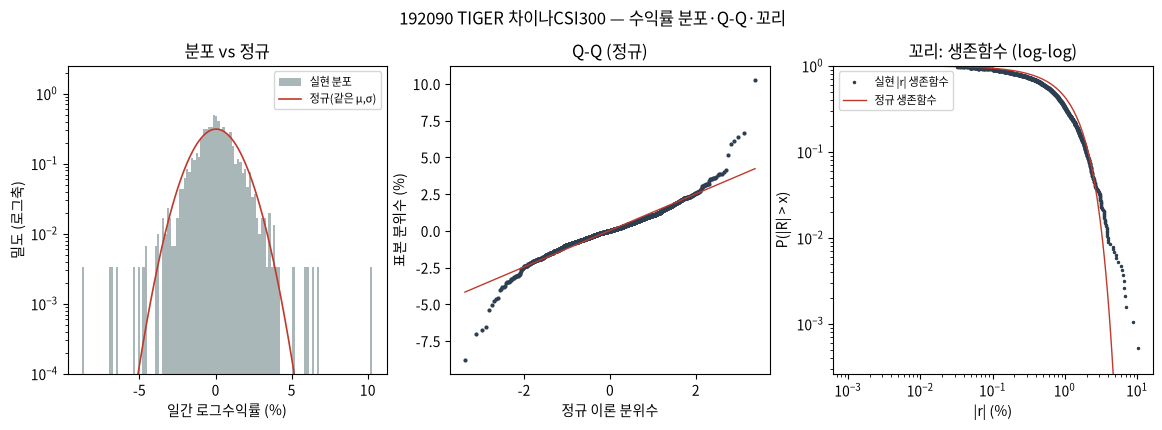

In [4]:
F.fig03_distribution(c)

**WHAT THIS FIGURE MEASURES** — 왼쪽: 히스토그램(로그 밀도) vs 같은 평균·표준편차의 정규. 가운데: 정규 Q-Q. 오른쪽: |r| 생존함수 P(|R|>x) log-log, 빨강 = 정규 기대치.

**WHAT WE SEE** — skew 0.04, excess kurtosis 6.1 → 상위 3일 제거 시 3.2. 일간 Q01 -3.37% / Q99 3.43%. Q-Q 양 끝이 직선에서 벗어나면 정규보다 두꺼운 꼬리.

**WHY IT MATTERS FINANCIALLY** — 첨도가 소수 날짜에 좌우되면 '이 자산은 원래 꼬리가 두껍다'가 아니라 '몇 날의 기억'이다. 리스크 지표(VaR 등)를 정규 가정으로 만들면 꼬리를 과소평가한다.

**WHAT WE CANNOT CONCLUDE** — dq_flags.csv 가 2024-10-07, 2024-10-08 을 isolated_spike_reversal(다음날 되돌림) 후보로 표시한다. 이 날의 극단값이 기초자산 움직임인지 ETF 가격 괴리인지는 NAV 없이 구분할 수 없다.

## Fig 4. rolling 변동성 (20/60일) 과 연도별 변동성

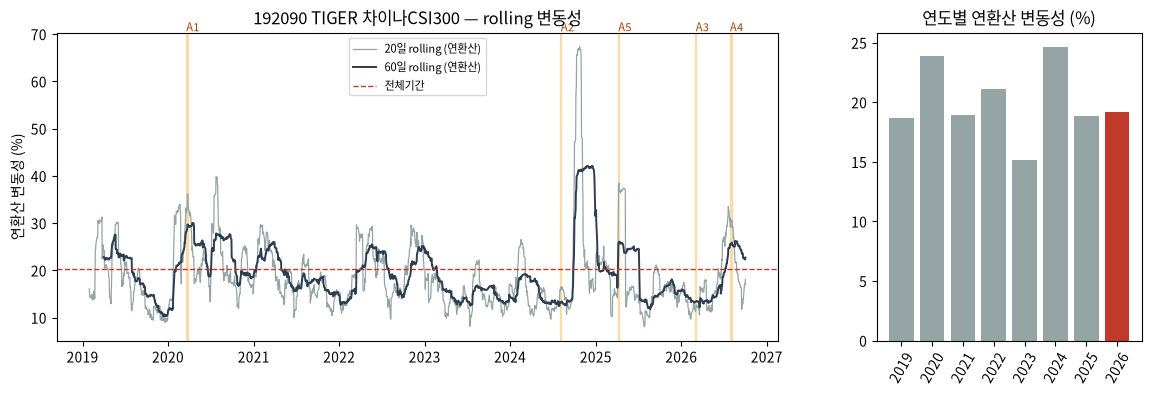

In [5]:
F.fig04_rolling_vol(c)

**WHAT THIS FIGURE MEASURES** — 왼쪽: 20일·60일 rolling std ×√252, 점선 = 전체기간. 오른쪽: 연도별 연환산 변동성 (빨강 = 2026).

**WHAT WE SEE** — 전체 20.3%, 2019-25 20.4%, 2026 19.2% → 비율 0.94×. 연도별: 2019 19%, 2020 24%, 2021 19%, 2022 21%, 2023 15%, 2024 25%, 2025 19%, 2026 19%.

**WHY IT MATTERS FINANCIALLY** — 변동성은 국면 변수다. 전체기간 평균으로 '평시'를 정의하면 2020·2026 같은 고변동 구간이 기준선을 끌어올린다. universe 비교에서는 2026 비율이 국내주식 국면을 가르는 축이다 (CL-30).

**WHAT WE CANNOT CONCLUDE** — 기초시장 거래시간이 KRX 와 다르다 (KRX 거래, 중국장(KST 10:30-16:00)과 부분 중첩 → 동일일 반영 일부, 중국 휴장일 상이). 같은 날짜 수익률의 상관·β 는 비동기로 과소추정될 수 있으며 (CL-15: 2일 비중첩 상관도 낮음) lead-lag 원인 분해는 불가.

## Fig 5. 상위 낙폭 에피소드 (깊이 · 하락기간 · 회복기간)

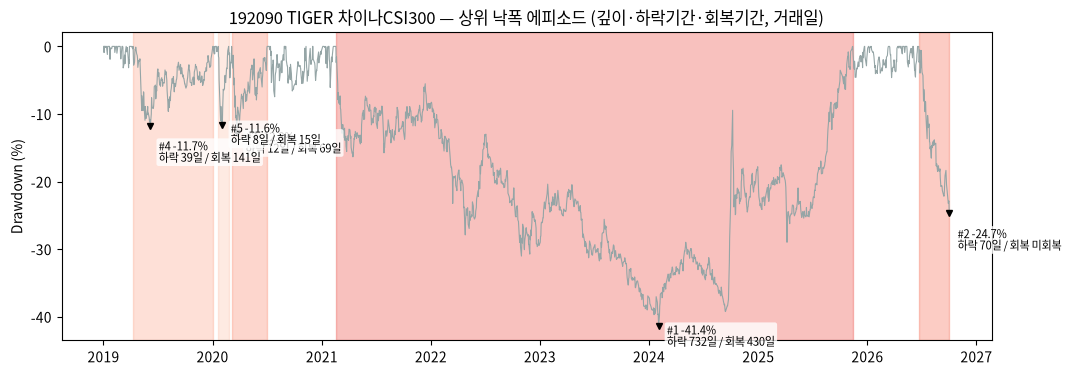

In [6]:
F.fig05_dd_episodes(c)

**WHAT THIS FIGURE MEASURES** — 회색 = 낙폭 곡선. 색 띠 = 깊이 상위 5개 에피소드의 고점→회복 구간 (미회복은 마지막 날까지). 주석 = 깊이·고점→저점 거래일·저점→회복 거래일.

**WHAT WE SEE** — #1 -41.4% (2021-02-17→2024-02-02, 하락 732일, 회복 430); #2 -24.7% (2026-06-22→2026-10-02, 하락 70일, 회복 미회복); #3 -12.8% (2020-03-05→2020-03-23, 하락 12일, 회복 69).

**WHY IT MATTERS FINANCIALLY** — 같은 깊이라도 회복기간이 다르면 위험의 성격이 다르다 (빠른 V자 vs 장기 레짐). 낙폭 에피소드는 이후 event window 와 regime 정의의 후보 구간을 준다.

**WHAT WE CANNOT CONCLUDE** — 회복 여부는 분배 소급조정 가격(DEC-3) 기준이다. 에피소드의 원인(거시·업종·상품 구조)은 가격만으로 식별하지 않는다.

## Fig 6. 거래량 배수와 수익률–거래량 joint

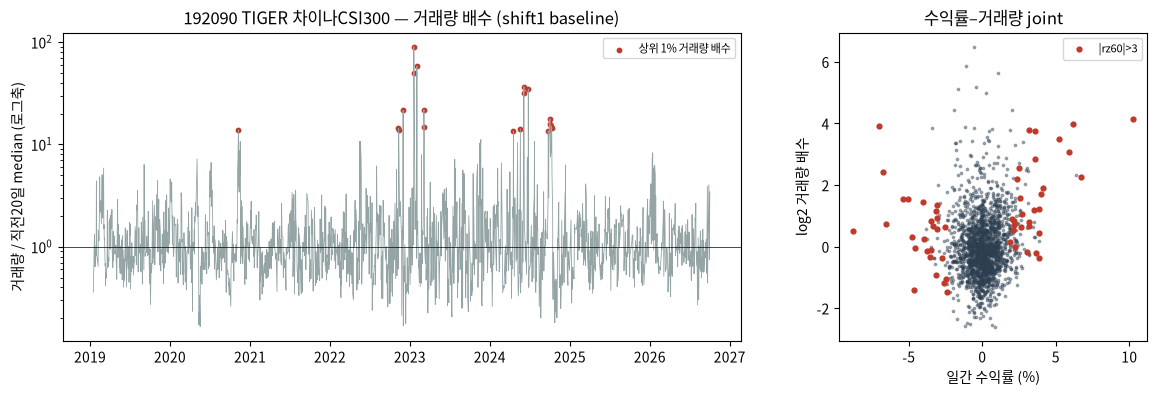

In [7]:
F.fig06_volume(c)

**WHAT THIS FIGURE MEASURES** — 왼쪽: 거래량 / 직전 20일 median (shift(1)) 로그축, 빨강 점 = 상위 1%. 오른쪽: x=일간 수익률, y=log2 거래량 배수, 빨강 = |rz60|>3.

**WHAT WE SEE** — 극단일 거래량 배수 median: − 극단 1.46×, + 극단 2.27× (전체 일 median 0.94×). corr(|r|, log 거래량배수) = 0.259. 거래량배수 Q99 = 12.0×.

**WHY IT MATTERS FINANCIALLY** — 가격 극단이 거래량 급증을 동반하는지(정보 충격/강제 매매)와 방향 비대칭(급락일 vs 급등일)은 CL-26 의 상품유형별 반대 패턴과 직접 연결된다.

**WHAT WE CANNOT CONCLUDE** — 기초시장 거래시간이 KRX 와 다르다 (KRX 거래, 중국장(KST 10:30-16:00)과 부분 중첩 → 동일일 반영 일부, 중국 휴장일 상이). 같은 날짜 수익률의 상관·β 는 비동기로 과소추정될 수 있으며 (CL-15: 2일 비중첩 상관도 낮음) lead-lag 원인 분해는 불가.

## Fig 7. benchmark 대비 동일일 산점도와 OLS

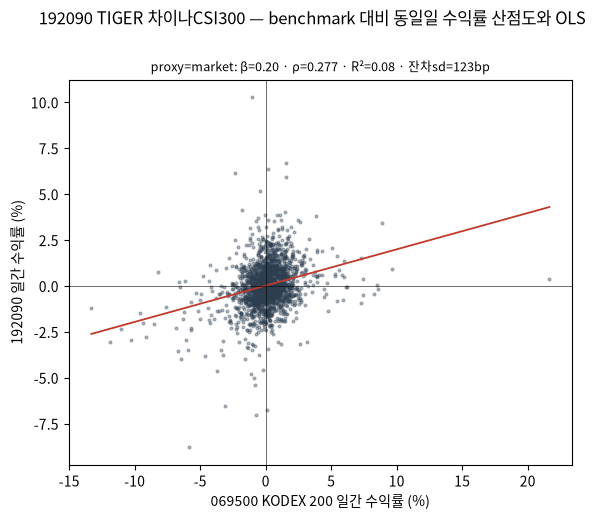

In [8]:
F.fig07_benchmark_scatter(c)

**WHAT THIS FIGURE MEASURES** — x = 비교 ETF 일간 수익률, y = 192090 일간 수익률, 빨강 = OLS 적합. 제목 = β, Pearson ρ, R², 잔차 표준편차(bp). 비교 ①proxy 069500 ②market 069500.

**WHAT WE SEE** — proxy 069500: β=0.20, ρ=0.277, Spearman=0.269, R²=0.08, 잔차sd=123bp. market 069500: β=0.20, ρ=0.277, Spearman=0.269, R²=0.08, 잔차sd=123bp.

**WHY IT MATTERS FINANCIALLY** — β 는 시장 1 움직임당 민감도, 잔차 sd 는 시장으로 설명되지 않는 고유 변동 크기다. 이상 탐지에서 '시장 공통분을 뺀 상대 움직임'을 쓸지 결정하는 기준이 된다.

**WHAT WE CANNOT CONCLUDE** — 기초시장 거래시간이 KRX 와 다르다 (KRX 거래, 중국장(KST 10:30-16:00)과 부분 중첩 → 동일일 반영 일부, 중국 휴장일 상이). 같은 날짜 수익률의 상관·β 는 비동기로 과소추정될 수 있으며 (CL-15: 2일 비중첩 상관도 낮음) lead-lag 원인 분해는 불가.

## Fig 8. rolling 120일 상관과 β

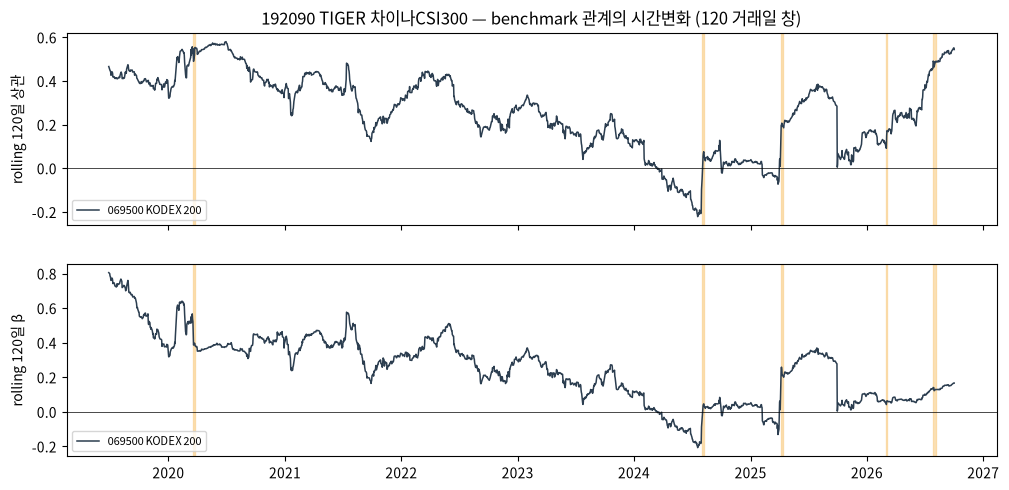

In [9]:
F.fig08_rolling_corr_beta(c)

**WHAT THIS FIGURE MEASURES** — 120 거래일 창의 Pearson 상관(위)과 β(아래). 검정 = market 069500, 주황 = proxy 069500 (같으면 하나만). 주황 띠 = anchor.

**WHAT WE SEE** — market 상관 범위 -0.22 (2024-07-19) ~ 0.58 (2020-06-30). 하위기간 상관: 2019-21 0.419 vs 2022-26 0.225.

**WHY IT MATTERS FINANCIALLY** — 관계 자체가 시간변화하는 상태 변수다. 충격기에 상관이 수렴하면 분산효과가 필요할 때 사라지고, 부호가 바뀌면 '헤지 자산' 라벨이 국면 한정이 된다.

**WHAT WE CANNOT CONCLUDE** — 기초시장 거래시간이 KRX 와 다르다 (KRX 거래, 중국장(KST 10:30-16:00)과 부분 중첩 → 동일일 반영 일부, 중국 휴장일 상이). 같은 날짜 수익률의 상관·β 는 비동기로 과소추정될 수 있으며 (CL-15: 2일 비중첩 상관도 낮음) lead-lag 원인 분해는 불가. universe.csv structural_notes: [OBS] Category=4. 중국 휴장(춘절·국경절) 시 가격 정체 가능 [ANA]

## Fig 9. market reference (069500) 대비 누적 상대수익

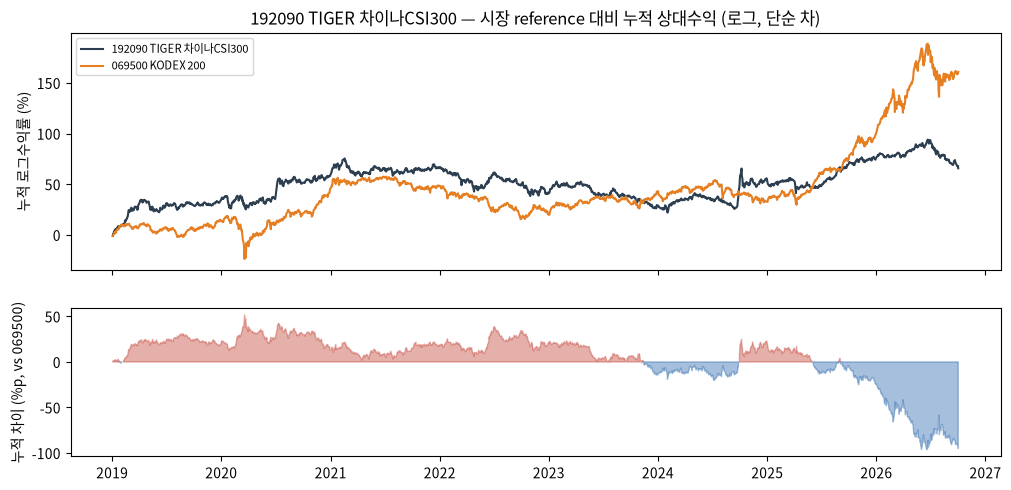

In [10]:
F.fig09_relative(c)

**WHAT THIS FIGURE MEASURES** — 위: 본 ETF 와 069500 의 누적 로그수익률. 아래: 누적 차이 Σ(r − r_market) %p (빨강 = 앞섬, 파랑 = 뒤처짐). β 조정 없음.

**WHAT WE SEE** — 본 ETF 누적 65.7%, 누적 차이 -95.1%p (β 조정 없는 단순 차).

**WHY IT MATTERS FINANCIALLY** — 상대수익이 장기 추세를 가지면 시장 factor 외 고유 factor(업종·자산군·통화)가 존재한다는 뜻이고, 이상 탐지 시 '시장 대비 초과' 정의의 기준선을 준다.

**WHAT WE CANNOT CONCLUDE** — β 조정을 하지 않았으므로 고β ETF 의 상대수익은 시장 방향을 그대로 반영한다. 상대 성과를 운용 능력이나 알파로 해석할 수 없다.

## Fig 10. robust-z 극단일 타임라인 (+/− 분리)

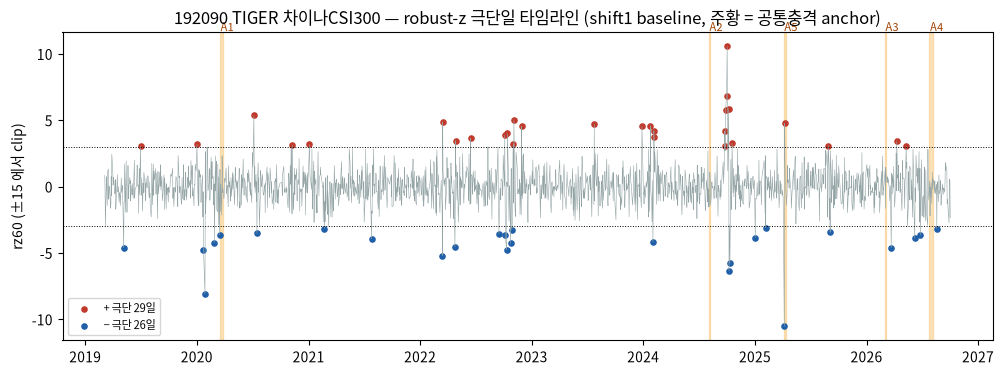

In [11]:
F.fig10_extreme_timeline(c)

**WHAT THIS FIGURE MEASURES** — rz60 = (r − 직전60일 median)/(1.4826·직전60일 MAD), shift(1) 로 당일 미포함. 점선 = ±3. 빨강 = + 극단, 파랑 = − 극단, 주황 띠 = 공통충격 anchor. 표시는 ±15 에서 clip.

**WHAT WE SEE** — |rz60|>3: + 29일 / − 26일. 상위 |rz| 5일: 2024-10-02 +10.28% (rz +10.6); 2025-04-07 -8.78% (rz -10.5); 2020-01-28 -6.52% (rz -8.1); 2024-09-30 +6.15% (rz +6.8); 2024-10-08 -7.00% (rz -6.3).

**WHY IT MATTERS FINANCIALLY** — +/− 극단을 분리해야 급등·급락의 빈도·군집이 다르다는 점이 보인다. anchor 와 겹치는 극단은 공통충격, 겹치지 않는 극단은 고유충격 후보다.

**WHAT WE CANNOT CONCLUDE** — dq_flags.csv 가 2024-10-07, 2024-10-08 을 isolated_spike_reversal(다음날 되돌림) 후보로 표시한다. 이 날의 극단값이 기초자산 움직임인지 ETF 가격 괴리인지는 NAV 없이 구분할 수 없다.

## Fig 11. 공통충격 anchor 전후 경로

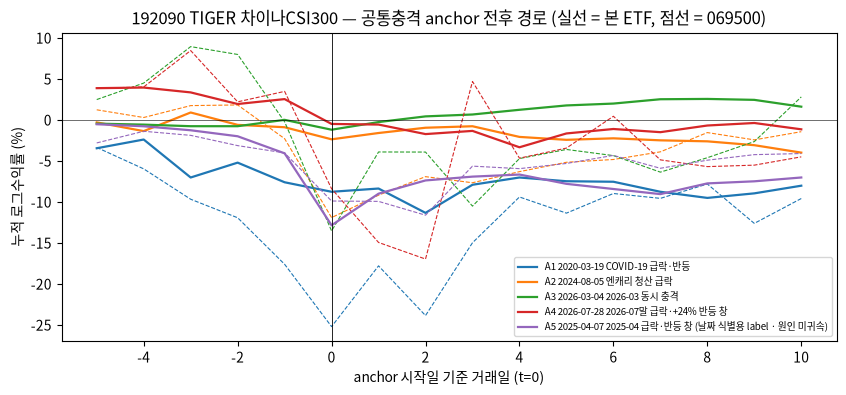

In [12]:
F.fig11_event_window(c)

**WHAT THIS FIGURE MEASURES** — 각 anchor 시작일 t=0 기준 −5~+10 거래일 누적 로그수익률. 실선 = 본 ETF, 점선 = 069500. anchor 정의는 config/event_anchors.csv.

**WHAT WE SEE** — anchor 구간(시작~끝) 누적 수익률: A1 -0.3%, A2 -1.5%, A3 -1.2%, A4 -5.9%, A5 -2.8%.

**WHY IT MATTERS FINANCIALLY** — 공통충격에 대한 반응 방향·크기·회복 속도가 상품군 정체성(동반 하락, 반대 방향, 무관)을 가장 직접적으로 보여준다 (CL-22/27).

**WHAT WE CANNOT CONCLUDE** — 기초시장 거래시간이 KRX 와 다르다 (KRX 거래, 중국장(KST 10:30-16:00)과 부분 중첩 → 동일일 반영 일부, 중국 휴장일 상이). 같은 날짜 수익률의 상관·β 는 비동기로 과소추정될 수 있으며 (CL-15: 2일 비중첩 상관도 낮음) lead-lag 원인 분해는 불가.

## 결론 ↔ 지지 figure
| # | 결론 (OBSERVATION) | 지지 figure | 근거 수치 |
|---|---|---|---|
| 1 | 평소 변동성 규모는 연 20.3%, 2026 은 2019-25 대비 0.94× | Fig 4, Fig 2 | vol_2026 19.2% |
| 2 | 꼬리 두께 중 소수 날짜 기여 = kurt 6.1 → trim3 3.2 | Fig 3 | Q01/Q99 -3.37%/3.43% |
| 3 | 시장(069500) 민감도 β=0.20, ρ=0.277; proxy(069500) β=0.20, ρ=0.277 | Fig 7 | 잔차sd 123bp |
| 4 | 시장 관계는 시간변화: 120일 상관 -0.22~0.58, 2019-21 0.42 vs 2022-26 0.23 | Fig 8 | — |
| 5 | 최대낙폭 -41.4% (2024-02-02), 회복 2025-11-13 | Fig 1, Fig 5 | — |
| 6 | 극단일(|rz60|>3) + 29 / − 26, 정의 민감 | Fig 10 | top: 2024-10-02 |
| 7 | 공통충격 반응: A1 -0.3%, A2 -1.5%, A3 -1.2%, A4 -5.9%, A5 -2.8% | Fig 11 | — |
| 8 | 시장 대비 누적 차이 -95.1%p (β 미조정) — 비국내주식이라 KOSPI200 대비 누적차는 참고용 (결론 강등) | Fig 9 | — |
| 9 | 극단일 거래량 배수 −1.46× / +2.27× vs 전체 0.94× | Fig 6 | — |

**이 notebook 이 주장하지 않는 것**: 인과(왜 움직였는가), 예측, 매매 신호. 모든 관계는 동일일 통계적 동행이다.

**ETF별 한계 요약**: - dq_flags.csv 가 2024-10-07, 2024-10-08 을 isolated_spike_reversal(다음날 되돌림) 후보로 표시한다. 이 날의 극단값이 기초자산 움직임인지 ETF 가격 괴리인지는 NAV 없이 구분할 수 없다. - 기초시장 거래시간이 KRX 와 다르다 (KRX 거래, 중국장(KST 10:30-16:00)과 부분 중첩 → 동일일 반영 일부, 중국 휴장일 상이). 같은 날짜 수익률의 상관·β 는 비동기로 과소추정될 수 있으며 (CL-15: 2일 비중첩 상관도 낮음) lead-lag 원인 분해는 불가. - universe.csv structural_notes: [OBS] Category=4. 중국 휴장(춘절·국경절) 시 가격 정체 가능 [ANA]